# How to tune thresholds to improve an existing classifier ?

In a Machine Learning project, the performance of the model is a key factor of success. In this notebook we aim at covering some methods to improve existing models with a proper tuning of the threshold used to classify.

As the focus of this notebook is working with existing models, we won't work much on data and hyperparameter tuning.

In [1]:
import numpy as np; np.random.seed(42)
import pandas as pd

df = pd.read_csv("JobChange.csv")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## Preparation

As said in the introduction, we won't work much on data and hyperparameter tuning. We will need three datasets :
* **Training** : to train the model which we'll tune the treshold
* **Validation** : to find the right threshold
* **Test** : check the improvement (if any!)


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["target", "enrollee_id"])
y = df["target"]

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, stratify=y_train_valid)

print(f"X_train: {X_train.shape[0]} observations with {100*y_train.mean():.2f}% of positive class")
print(f"X_valid: {X_valid.shape[0]} observations with {100*y_valid.mean():.2f}% of positive class")
print(f"X_test: {X_test.shape[0]} observations with {100*y_test.mean():.2f}% of positive class")

X_train: 10776 observations with 24.94% of positive class
X_valid: 3592 observations with 24.94% of positive class
X_test: 4790 observations with 24.93% of positive class


We use the [`tabular_learned`](https://skrub-data.org/stable/reference/generated/skrub.tabular_learner.html) function from [skrub](https://skrub-data.org/stable/index.html). It will perform both data preparation and model training. It gives great baseline model upon which Data Scientist can work on to improve.

In [3]:
from skrub import tabular_learner

model = tabular_learner("classification").fit(X_train, y_train)


Let's check its performance already :

In [4]:
from sklearn.metrics import f1_score

for (dataset, X_compute, y_true) in zip(["Train", "Valid", "Test"], [X_train, X_valid, X_test], [y_train, y_valid, y_test]):
    y_pred = model.predict(X_compute)
    score = f1_score(y_pred=y_pred, y_true=y_true)
    print(f"{dataset}: \tscore = {score:.4f}")

Train: 	score = 0.6610
Valid: 	score = 0.5845
Test: 	score = 0.5889


These are good performances given that it is only one line of code. Still, we can improve them using the right threshold

## Finding the right threshold

Every Machine Learning model in classification can output a *score* often interpreted as a probability. To transform this score into a prediction, we choose by default the threshold 0.5 : every prediction above 0.5 will be interpreted as being from the class of interest.
But the 0.5 threshold is arbitrary, and is not always the best one. We are going to compute precision, recall and f1-score for some thresholds and inspect visually the performance.

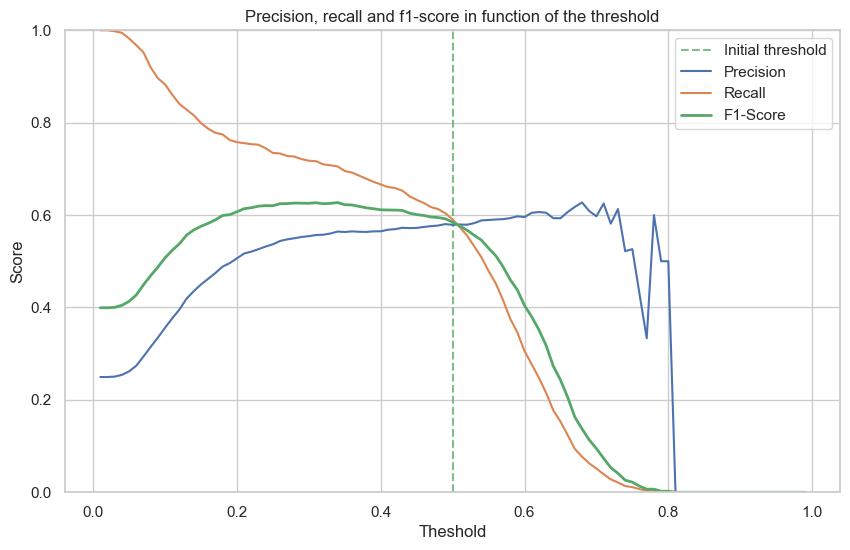

In [39]:
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style="whitegrid")

thresholds = np.linspace(start=0.01, stop=0.99, num=99)

recall_scores = []
precision_scores = []
f1_scores = []

for threshold in thresholds:
    y_pred_proba = model.predict_proba(X_valid)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    recall = recall_score(y_valid, y_pred)
    recall_scores.append(recall)

    precision = precision_score(y_valid, y_pred) if sum(y_pred) > 0 else 0
    precision_scores.append(precision)

    f1 = f1_score(y_valid, y_pred)
    f1_scores.append(f1)




plt.figure(figsize=(10, 6))
plt.axvline(x=0.5, ls='--', alpha=0.75, label="Initial threshold", color=sns.color_palette()[2])
plt.plot(thresholds, precision_scores, label="Precision", color=sns.color_palette()[0])
plt.plot(thresholds, recall_scores, label="Recall", color=sns.color_palette()[1])
plt.plot(thresholds, f1_scores, label="F1-Score", color=sns.color_palette()[2], lw=2)

plt.ylim(0, 1)
plt.title("Precision, recall and f1-score in function of the threshold")
plt.xlabel("Theshold")
plt.ylabel("Score")
plt.legend()
plt.show()


Clearly, a lower threshold would gives us a better f1-score. We can manually find that value, or we can use the [`TunedThresholdClassifierCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html) class.

As our model is already fitted, we don't want any more training so we are going to set the `refit` parameter to `False` and the `cv` parameter to `'refit'` as suggested in the documentation. We are using our validation set to find the best threshold as the training set would lead to overfitting and a methodology problem in our setting.

In [5]:
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import make_scorer

classifier = TunedThresholdClassifierCV(estimator=model, scoring=make_scorer(f1_score), thresholds=100, cv="prefit", refit=False).fit(X_valid, y_valid)

for (dataset, X_compute, y_true) in zip(["Train", "Valid", "Test"], [X_train, X_valid, X_test], [y_train, y_valid, y_test]):
    y_pred = classifier.predict(X_compute)
    score = f1_score(y_pred=y_pred, y_true=y_true)
    print(f"{dataset}: \tscore = {score:.4f}")

Train: 	score = 0.6845
Valid: 	score = 0.6270
Test: 	score = 0.6371


It has indeed improved the performance of the classifier accross all sets ! One can inspect the `classifier` variable to get the best threshold :

In [40]:
print(f"Best threshold: {classifier.best_threshold_:.4f}")

Best threshold: 0.3345


Which is the value corresponding to the graphics. Note that the `classifier` model is the exact same as the `model` but its default threshold is different (0.33 instead of 0.5).